# Trick sequences (gaussian sampling)


In [10]:
from pathlib import Path
import math
import random

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import pandas as pd

from aitraf.data_ops.pose_and_bbox_extraction import _iter_frames
from aitraf.data_ops.schema import LabelsSchema
from aitraf.processing.utils import sample_frame_indices
from aitraf.utils import get_video_rotation_deg

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
CLIPS_DIR = DATA_DIR / "clips"
LABELS_PATH = DATA_DIR / "labels.jsonl"
EXPORT_DIR = PROJECT_ROOT / "notebooks" / "data" / "trick-taxonomies"

SAMPLE_FRAMES = 5
SAMPLING_DIST = "gaussian_stochastic"


In [11]:
labels_df = pd.read_json(LABELS_PATH, lines=True, dtype=LabelsSchema.types)
labels_df["video_id"] = labels_df["video"].apply(lambda x: Path(x).name)
labels_df.head()


annotation_id annotator                        created_at  \
0           182         1  2025-11-09 20:58:42.022118+00:00   
1           163         1  2025-11-09 20:54:35.712942+00:00   
2           183         1  2025-11-09 20:58:57.738689+00:00   
3           135         1  2025-11-09 19:11:56.773045+00:00   
4           184         1  2025-11-09 20:59:06.227576+00:00   

0                                   <NA>             <NA>  477    right   
1                Too short and too slow                 2  456    right   
2                                   <NA>             <NA>  479    right   
3  Really short. Barely counts as grind.                1  482    right   
4                                   <NA>             <NA>  480    right   

   lead_time    person      trick                        updated_at  \
0     12.241       Max   top-soul  2025-11-09 20:58:42.022134+00:00   
1     22.179  Henrikas  fs-royale  2025-12-30 15:37:52.180275+00:00   
2      8.778  Henrikas       soul  2025-11-09 20:58:57.738699+00:00   
3     39.935  Henrikas      mizou  2025-12-30 15:38:42.621260+00:00   
4      7.319       Max       soul  2025-11-09 20:59:06.227592+00:00   

                                               video  \
0  s3://aitraf/clips/25-10-31 19-54-19 5689-00.05...   
1  s3://aitraf/clips/25-10-31 19-46-26 5688-00.04...   
2  s3://aitraf/clips/25-10-31 19-54-19 5689-00.06...   
3  s3://aitraf/clips/25-10-31 19-54-19 5689-00.08...   
4  s3://aitraf/clips/25-10-31 19-54-19 5689-00.06...   

                                            video_id  
0  25-10-31 19-54-19 5689-00.05.42.439-00.05.47.0...  
1  25-10-31 19-46-26 5688-00.04.02.842-00.04.07.6...  
2  25-10-31 19-54-19 5689-00.06.17.639-00.06.23.9...  
3  25-10-31 19-54-19 5689-00.08.03.363-00.08.07.9...  
4  25-10-31 19-54-19 5689-00.06.25.469-00.06.29.4...

In [12]:
def center_crop_square(frame):
    height, width = frame.shape[:2]
    size = min(height, width)
    top = (height - size) // 2
    left = (width - size) // 2
    return frame[top : top + size, left : left + size]


def load_gaussian_frames(row):
    clip_path = CLIPS_DIR / row["video_id"]
    rotation_deg = get_video_rotation_deg(clip_path)
    frames = list(_iter_frames(clip_path, rotation_deg))
    indices = sample_frame_indices(
        len(frames),
        SAMPLE_FRAMES,
        SAMPLING_DIST,
        source=clip_path,
    )
    return [center_crop_square(frames[idx]) for idx in indices]


def pick_trick_row(trick_rows, trick):
    rows = list(trick_rows)
    if not rows:
        raise RuntimeError(f"No rows for trick '{trick}'.")

    scored = []
    for row in rows:
        score = row.get("execution_score")
        if score is None:
            continue
        if isinstance(score, float) and math.isnan(score):
            continue
        scored.append((score, row))

    if scored:
        return max(scored, key=lambda item: item[0])[1]

    return random.choice(rows)


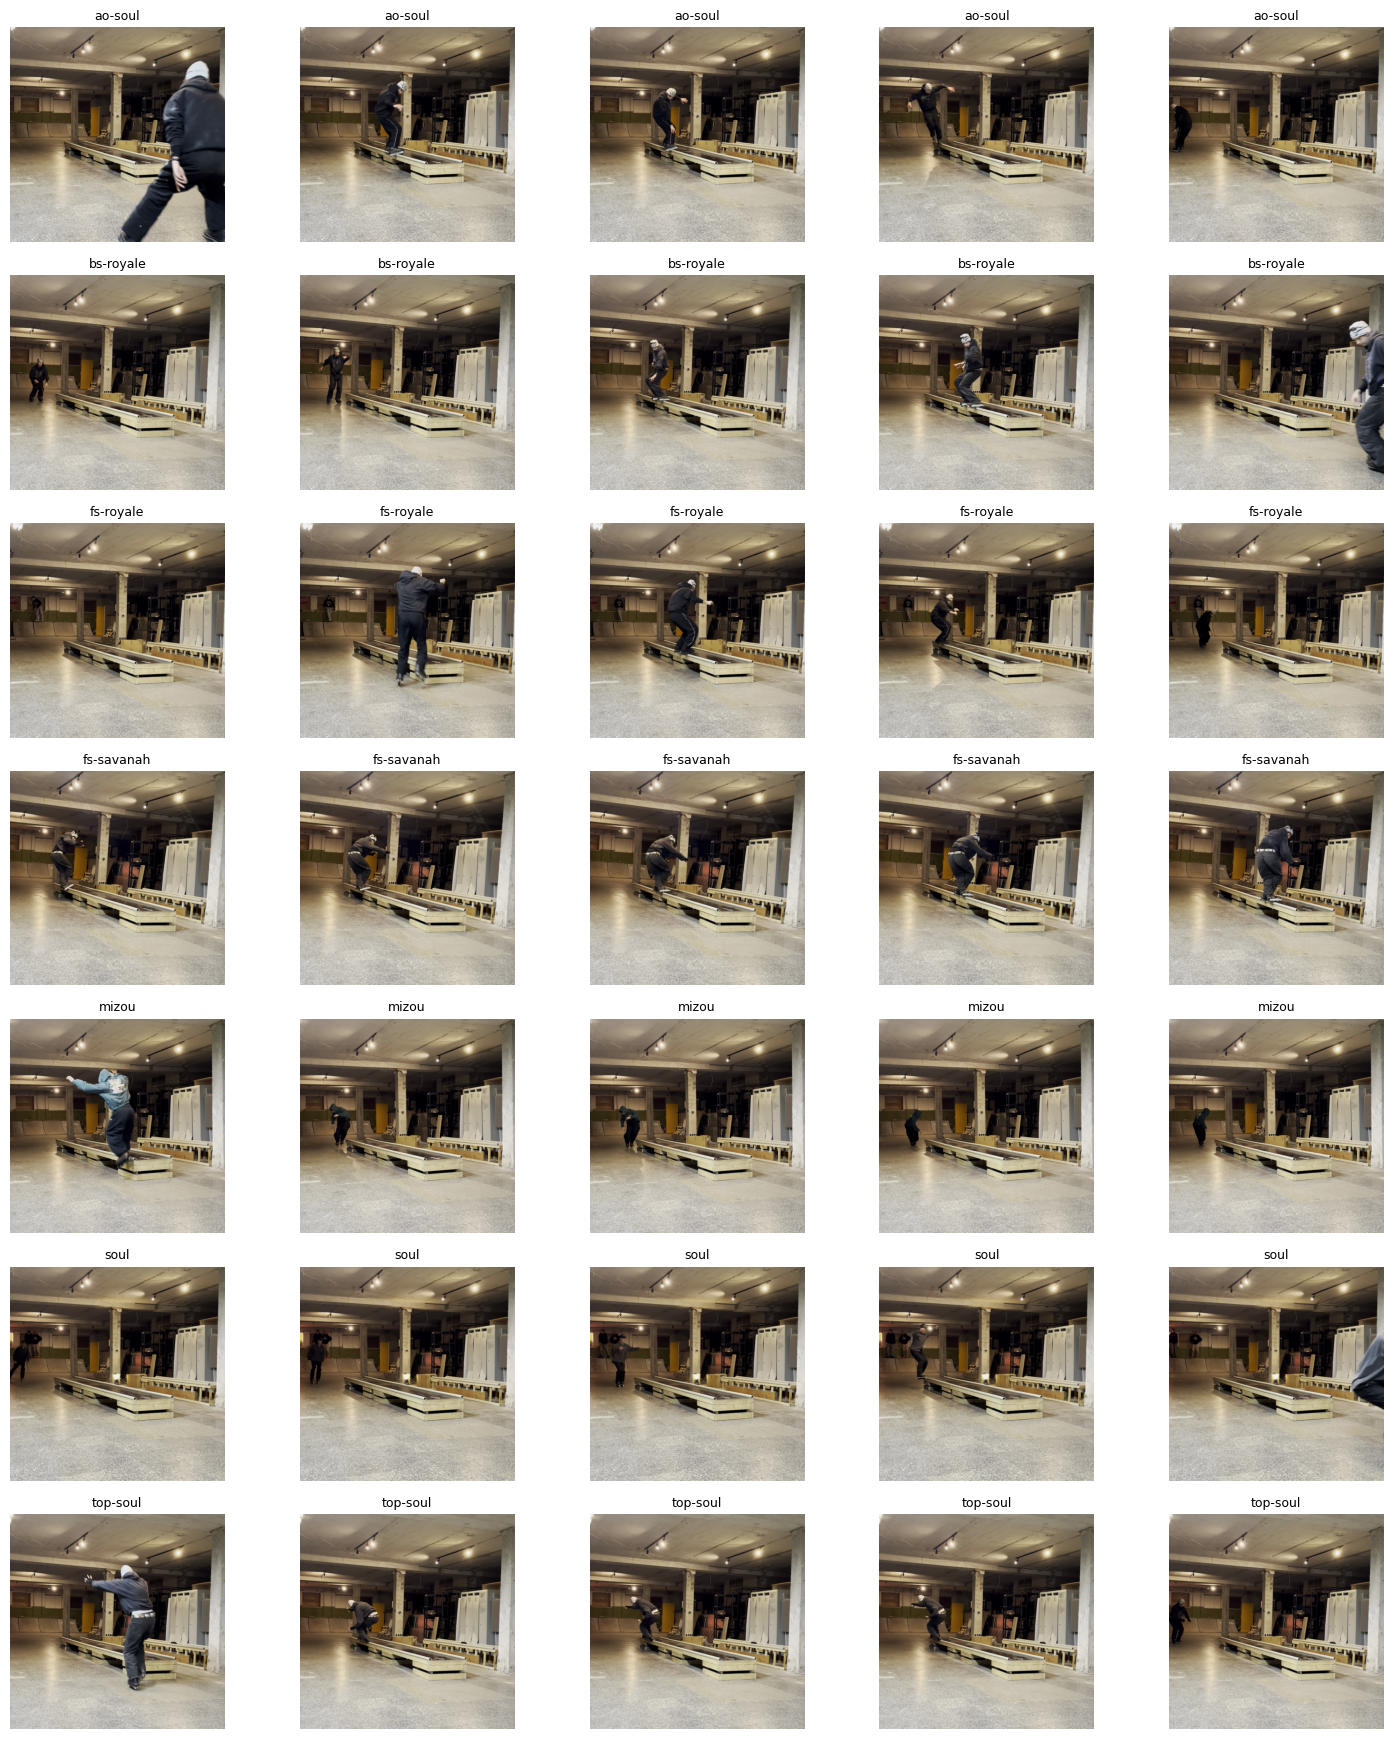

In [13]:
tricks = sorted(labels_df["trick"].dropna().unique().tolist())

fig, axes = plt.subplots(
    len(tricks),
    SAMPLE_FRAMES,
    figsize=(SAMPLE_FRAMES * 3, len(tricks) * 2.5),
    squeeze=False,
)

for row_idx, trick in enumerate(tricks):
    trick_rows = labels_df[labels_df["trick"] == trick].to_dict(
        orient="records"
    )
    row = pick_trick_row(trick_rows, trick)
    frames = load_gaussian_frames(row)

    export_dir = EXPORT_DIR / trick
    export_dir.mkdir(parents=True, exist_ok=True)

    for col_idx in range(SAMPLE_FRAMES):
        frame = frames[col_idx]
        image_path = export_dir / f"{col_idx + 1}.png"
        imageio.imwrite(image_path, frame)

        ax = axes[row_idx][col_idx]
        ax.imshow(frame)
        ax.set_title(trick, fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()
